# C++的引用

# 1. 引用

## 1.1 引用基本语法

① 作用：给变量起别名。

② 语法：数据类型 &别名 = 原名

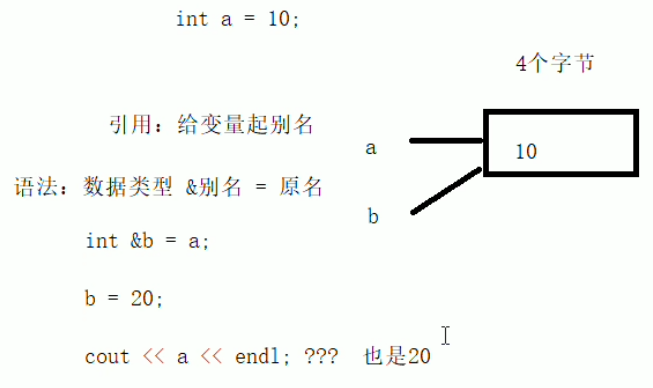

In [ ]:
#include <iostream>
using namespace std;

int main()
{
    //引用基本语法
    //数据类型 &别名 = 原名

    int a = 10;
    //创建引用
    int& b = a;

    b = 100;

    cout << "a= " << a << endl;
    cout << "b= " << a << endl;

    system("pause");

    return 0;

}

运行结果：  
 - a= 100  
 - b= 100  
 - 请按任意键继续. . .

## 1.2 引用注意事项

① 引用必须初始化。

② 引用在初始化后，不可以改变。

In [ ]:
#include <iostream>
using namespace std;

int main()
{
    //1、引用必须初始化
    int a = 10;
    int &b = a; // int &b; 是错误的，必须要初始化

    //2、引用在初始化后，不可以改变
    int c = 20;
    b = c;   // 赋值操作，而不是更改引用。把 c = 20 的数据20给了 b 指向的内存的数据，而 a、b 的指向的内存是一样的。
             // 这里并不是 b 指向 c 的内存。

    cout << "a = " << a << endl;  //a内存中数据变了
    cout << "b = " << b << endl;
    cout << "c = " << c << endl;

    system("pause");

    return 0;

}

运行结果：  
 - a = 20  
 - b = 20  
 - c = 20  
 - 请按任意键继续. . .

## 1.3 引用做函数参数

① 函数传参时，可以利用引用的技术让形参修饰实参。

② 可以简化指针修改实参。

总结:通过引用参数产生的效果同按地址传递是一样的。引用[的语法更清楚简单

In [ ]:
#include <iostream>
using namespace std;

//1、值传递
void mySwap01(int a,int b)
{
    int temp = a;
    a = b;
    b = temp;
}

//2、地址传递
void mySwap02(int * a, int * b)
{
    int temp = *a;
    *a = *b;
    *b = temp;
}

//2、引用传递
//这里面的&a的实参为a(恰巧为a，恰巧一样)的别名，对&a中的a操作修改，就是对实参a修改
void mySwap03(int &a, int &b)  
{
    int temp = a;
    a = b;
    b = temp;
}

int main()
{
    int a = 10;
    int b = 20;

    mySwap01(a, b);  //值传递，形参不会修饰实参
    
    cout << "a = " << a << endl;
    cout << "b = " << b << endl;

    mySwap02(&a, &b); //地址传递，形参会修饰实参

    cout << "a = " << a << endl;
    cout << "b = " << b << endl;

    mySwap03(a, b); //引用传递，形参会修饰实参

    cout << "a = " << a << endl;
    cout << "b = " << b << endl;

    system("pause");

    return 0;

}

运行结果：  
 - a = 10  
 - b = 20  
 - a = 20  
 - b = 10  
 - a = 10  
 - b = 20  
 - 请按任意键继续. . .

## 1.4 引用做函数返回值

① 引用是可以作为函数的返回值存在的。

② 不要返回局部变量引用。

③ 函数调用可以作为左值。

In [ ]:
#include <iostream>
using namespace std;

//引用做函数的返回值
//1、不要返回局部变量的引用
int& test01()
{
    int a = 10; //局部变量存放在四区中的栈区
    return a;
}

//2、函数的调用可以作为左值
int& test02()
{
    static int a = 10;  //加上关键字static，变成静态变量，存放在全局区，全局区上的数据在程序结束后释放掉
    return a;   //函数的返回值是a的一个引用
}

int main()
{
    /*
    int& ref = test01();
    cout << "ref = " << ref << endl; //第一次结果正确，是因为编译器做了保留
    cout << "ref = " << ref << endl; //第一次结果正确，是因为栈区a的内存已经释放
    */

    
    int& ref = test02();  //由于返回的是a的引用，所以要用引用来接收，这里用ref来接收，ref为原名a的别名
    cout << "ref = " << ref << endl; 
    cout << "ref = " << ref << endl; 
    cout << "ref = " << ref << endl; 

    test02() = 1000;   //对a的引用进行操作，相当于原名a赋值赋值为1000
    cout << "ref = " << ref << endl; //通过原名a的别名ref访问1000
    cout << "ref = " << ref << endl;

    system("pause");

    return 0;

}

运行结果：  
 - ref = 10  
 - ref = 10  
 - ref = 10  
 - ref = 1000  
 - ref = 1000  
 - 请按任意键继续. . .

## 1.5 引用本质

① 引用的本质在C++内部实现是一个指针常量。

② C++推荐引用计数，因为语法方便，引用本质是指针常量，但是所有的指针操作编译器都帮我们做了。

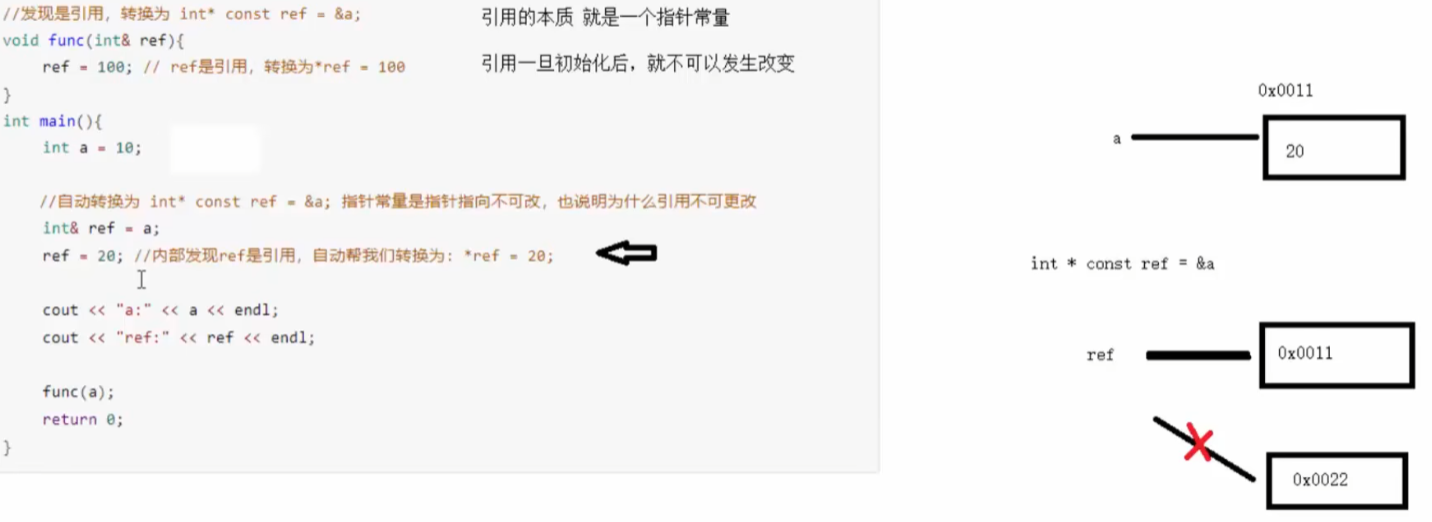

In [ ]:
#include <iostream>
using namespace std;

//发现是引用，转换为 int* const ref = &a;
void func(int& ref)
{
    ref = 100; //ref是引用，转换为 * ref = 100;
}

int main()
{
    int a = 10;

    //自动转换为 int * const ref = &a; 指针常量是指针不可改，引用不可更改别名。
    //虽然指针常量指向的地址不可以更改，但是地址中的值可以更改。
    int& ref = a;

    ref = 20; //内部发现ref是引用，自动帮我们转换为 *ref = 20; 解引用找到相应的数据改为20

    cout << "a：" << a << endl;
    cout << "ref："  << ref << endl;

    func(a);

    system("pause");

    return 0;

}

运行结果：  
 - a：20  
 - ref：20  
 - 请按任意键继续. . .

## 1.6 常量引用

① 作用：常量引用主要用来修饰形参，防止误操作。

② 在函数形参列表中，可以加const修饰形参，防止形参改变实参。

In [ ]:
#include <iostream>
using namespace std;

void showValue(const int& val)
{
    // val = 1000; 报错，不能修改了
    cout << "val = " << val << endl;
}

int main()
{
    //常量引用
    //使用场景：用来修饰形参，防止误操作

    /*
    int a = 10;
    int& ref = 10;  //报错，引用必须引一块合法的内存空间
    */

    //加上const之后，编译器代码修改为 int temp = 10; const in & ref = temp 
    const int& ref = 10;
    //ref = 20;  //加入const之后变为只读，不可以修改

    int a = 100;
    showValue(a);
    cout << "a = " << a << endl;

    system("pause");
    
    return 0;

}

运行结果：  
 - val = 100  
 - a = 100  
 - 请按任意键继续. . .